# AqSolDB Full Experiments Notebook

This notebook runs the **complete pipeline** end-to-end, importing directly from the project source files.
Every single hyperparameter is collected in **one cell** (Section 1) so you can tune everything from a single place.

**Pipeline overview**
```
Raw CSV
  └─► load_dataset()          clean SMILES, drop invalid rows
        ├─► Tabular path:     Morgan fingerprints + RDKit descriptors  → classical models + DNN
        └─► Graph path:       atom/bond features as PyG Data objects   → GNN models
```

**Sections**
1. Setup
2. **Master Hyperparameter Cell** ← change everything here
3. Data loading & cleaning
4. Tabular preprocessing
5. Graph preprocessing
6. Data splitting
7. Classical regression models
8. Dense neural network regression
9. Graph neural network regression
10. Results comparison
11. Hyperparameter tuning
12. Binary classification ablation

## 0 · Setup

Makes the repository importable whether you launch the notebook from `notebooks/` or from the project root.

In [43]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Locate project root regardless of where the notebook is launched from
CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "utils").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "utils").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise RuntimeError("Cannot locate project root. Run from repo root or notebooks/ folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/priyank1/Palash/FOML_GOD/FoML_Project


## 1 · Master Hyperparameter Cell

> **All knobs are here. Change values in this cell and re-run the notebook to try a new configuration.**

The cells below read these variables — you never need to edit anything past this section.

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
#  MASTER HYPERPARAMETER CELL
#  Edit values here, then run all cells below.
# ─────────────────────────────────────────────────────────────────────────────

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE    = 42          # global seed for everything

# ── Train / test split ───────────────────────────────────────────────────────
TEST_SIZE       = 0.20        # fraction of data held out for testing
VAL_FRACTION    = 0.15        # fraction of train used as validation (DNN & GNN only)

# ── Feature engineering (tabular path) ───────────────────────────────────────
# Options: "fingerprint" (1024-d), "descriptor" (12-d), "combined" (1036-d)
FEATURE_MODE        = "combined"
FINGERPRINT_RADIUS  = 2       # Morgan fingerprint radius
FINGERPRINT_SIZE    = 1024    # number of Morgan fingerprint bits
# Descriptor list used when FEATURE_MODE is "descriptor" or "combined"
DESCRIPTOR_NAMES = [
    "NumHDonors", "TPSA", "NumRotatableBonds", "BertzCT",
    "RingCount", "NumAromaticRings", "NumValenceElectrons",
    "LabuteASA", "HeavyAtomCount", "MolWt", "MolMR", "MolLogP",
]

# ── Graph feature variant (graph path) ───────────────────────────────────────
# Options: "atomic_number" (1-d), "atomic_number_degree" (2-d), "full" (3-d)
GRAPH_FEATURE_VARIANT = "full"

# ── Gaussian Process Regressor ────────────────────────────────────────────────
GP_LENGTH_SCALE     = 1.0     # RBF kernel length scale
GP_ALPHA            = 1e-6    # noise level (regularisation)

# ── Sklearn MLP Regressor ────────────────────────────────────────────────────
SKLEARN_MLP_HIDDEN_LAYERS    = (256, 128, 64)   # tuple of layer sizes
SKLEARN_MLP_ALPHA            = 1e-4             # L2 penalty
SKLEARN_MLP_LR_INIT          = 1e-3             # initial learning rate
SKLEARN_MLP_MAX_ITER         = 250              # maximum epochs

# ── PyTorch Dense Regressor ───────────────────────────────────────────────────
DNN_HIDDEN_DIMS     = (256, 128, 64)   # hidden layer sizes
DNN_DROPOUT         = 0.15            # dropout probability
DNN_EPOCHS          = 150             # training epochs
DNN_BATCH_SIZE      = 64              # mini-batch size
DNN_LR              = 1e-3            # Adam learning rate
DNN_WEIGHT_DECAY    = 1e-5            # Adam L2 weight decay

# ── Graph Neural Networks (all four models share these) ───────────────────────
GNN_HIDDEN_CHANNELS = 128             # hidden width used inside each GNN
GNN_EPOCHS          = 180             # training epochs
GNN_BATCH_SIZE      = 32              # mini-batch size
GNN_LR              = 5e-4            # Adam learning rate
GNN_WEIGHT_DECAY    = 1e-4            # Adam L2 weight decay

# ── Binary classification ablation ───────────────────────────────────────────
# Molecules with Solubility >= CLASSIFICATION_THRESHOLD are labelled 1 (soluble)
CLASSIFICATION_THRESHOLD    = -3.0
CLF_EPOCHS                  = 100     # epochs for DenseClassifier
CLF_BATCH_SIZE              = 64
CLF_LR                      = 1e-3
CLF_WEIGHT_DECAY            = 1e-5

# ── Which experiments to actually run ────────────────────────────────────────
# Set to True to execute a section; False to skip it (useful for quick reruns)
RUN_LINEAR_REGRESSION   = True
RUN_GAUSSIAN_PROCESS    = False   # slow on large feature sets; set True if you want it
RUN_SKLEARN_MLP         = True
RUN_DENSE_REGRESSOR     = True
RUN_GRAPH_CN            = True
RUN_GRAPH_NET           = True
RUN_GRAPH_SAGE          = True
RUN_GRAPH_MP            = True
RUN_TUNING              = False   # slow; runs full tuning sweeps
RUN_ABLATION            = False   # runs binary-classification ablation

print("Hyperparameters loaded.")

Hyperparameters loaded.


In [45]:
clean_frame['Solubility'].median()

np.float64(-2.61905)

In [46]:
clean_frame['Solubility'].count()

np.int64(9980)

In [47]:
clean_frame['Solubility'][clean_frame['Solubility'] > clean_frame['Solubility'].median()].count()

np.int64(4990)

In [48]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [49]:
import seaborn as sns

## 2 · Load and clean the dataset

`load_dataset()` is the shared entry-point used by every training script.

It reads the AqSolDB CSV, validates SMILES strings with RDKit, drops rows that cannot be parsed, and adds a `CanonicalSMILES` column.

In [50]:
from utils.data_utils import (
    DEFAULT_DESCRIPTOR_NAMES,
    build_classical_feature_matrix,
    build_graph_dataset,
    load_dataset,
    make_binary_labels,
    split_classical_data,
)
from utils.metrics import classification_metrics, regression_metrics
from utils.project_paths import DATASET_PATH, OUTPUTS_DIR

raw_frame   = pd.read_csv(DATASET_PATH)
clean_frame = load_dataset()

print(f"Raw rows   : {len(raw_frame)}")
print(f"Clean rows : {len(clean_frame)}")
print(f"Dropped    : {len(raw_frame) - len(clean_frame)}")
print(f"Solubility → mean={clean_frame['Solubility'].mean():.3f}  "
      f"std={clean_frame['Solubility'].std():.3f}  "
      f"min={clean_frame['Solubility'].min():.3f}  "
      f"max={clean_frame['Solubility'].max():.3f}")

display(clean_frame[["Name", "SMILES", "Solubility", "MolWt", "MolLogP"]].head())

[17:43:44] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:43:44] Explicit valence for atom # 5 N, 4, is greater than permitted


Raw rows   : 9982
Clean rows : 9980
Dropped    : 2
Solubility → mean=-2.890  std=2.368  min=-13.172  max=2.138


,Name,SMILES,Solubility,MolWt,MolLogP
0,"N,N,N-trimethyloctadecan-1-aminium bromide",[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,392.510,3.9581
1,Benzo[cd]indol-2(1H)-one,O=C1Nc2cccc3cccc1c23,-3.254767,169.183,2.4055
2,4-chlorobenzaldehyde,Clc1ccc(C=O)cc1,-2.177078,140.569,2.1525
3,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,756.226,8.1161
4,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,422.525,2.4854


## 3 · Dataset & Feature Visualizations

All charts below are computed directly from `clean_frame` and the hyperparameters you set in Section 1.

| Figure | What it shows |
|--------|---------------|
| 1 | Solubility distribution — histogram, KDE vs normal, Q-Q plot, box plot |
| 2 | Solubility by experimental group (box plots) |
| 3 | Pearson correlation heatmap across all descriptors |
| 4 | Key descriptor vs Solubility scatter plots with OLS trend lines |
| 5 | Distribution of every molecular descriptor |
| 6 | Feature correlation ranking with Solubility |
| 7 | Binary class split + MolLogP vs Solubility scatter |


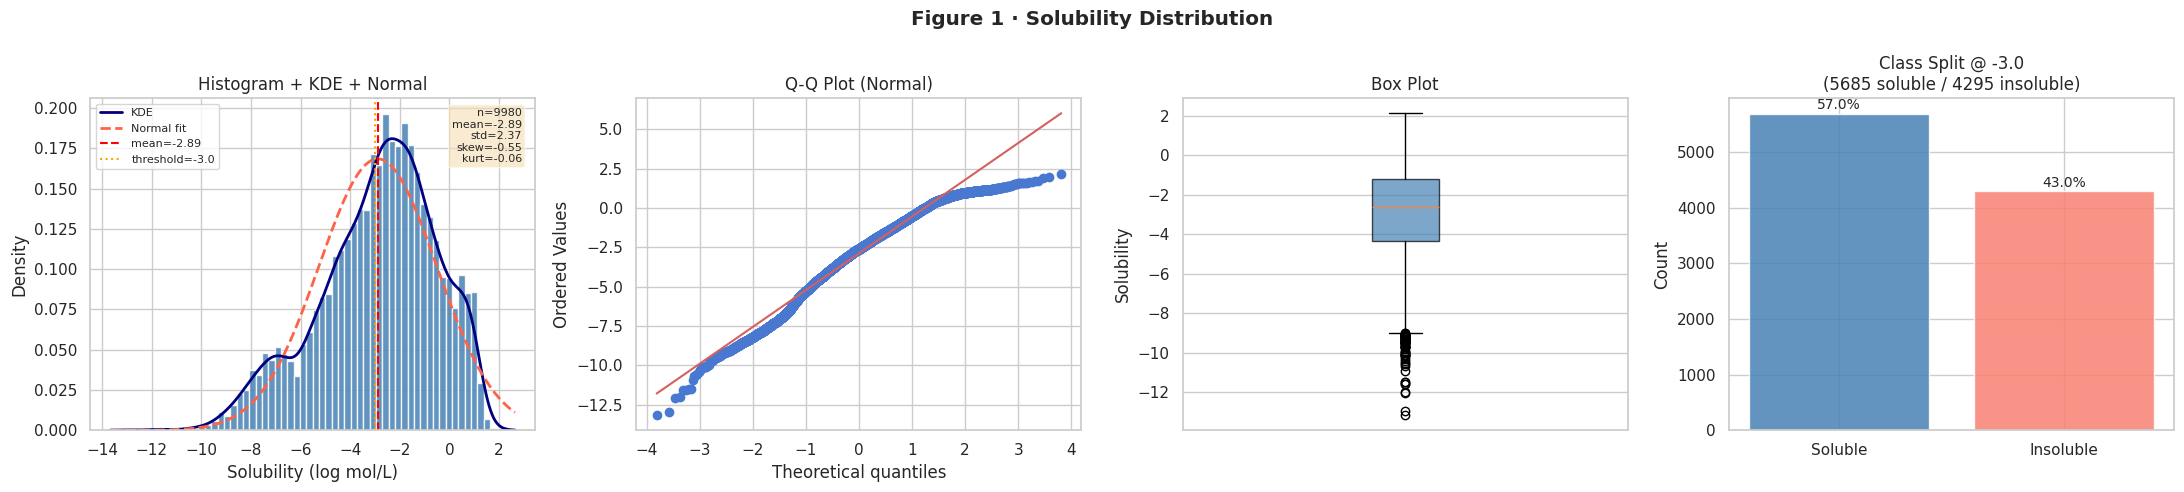

/tmp/ipykernel_106552/3269224837.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=groups, patch_artist=True, notch=False)


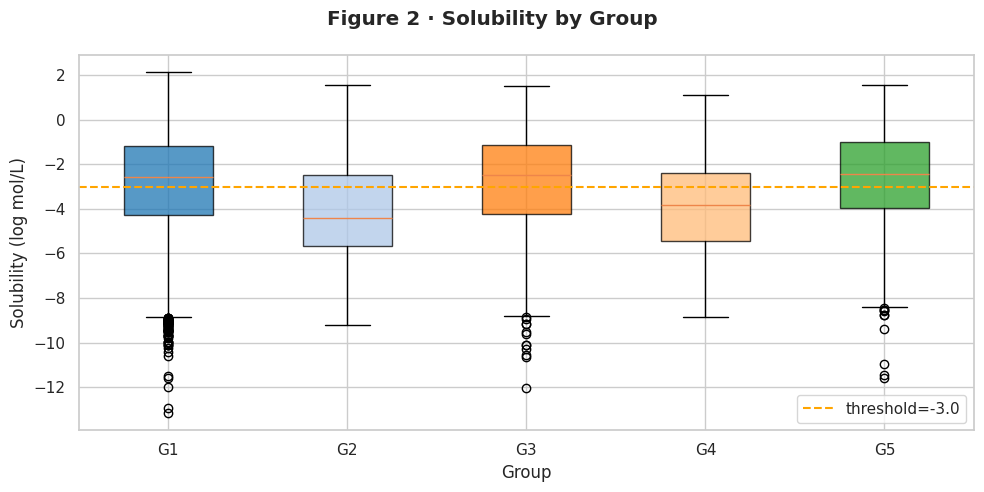

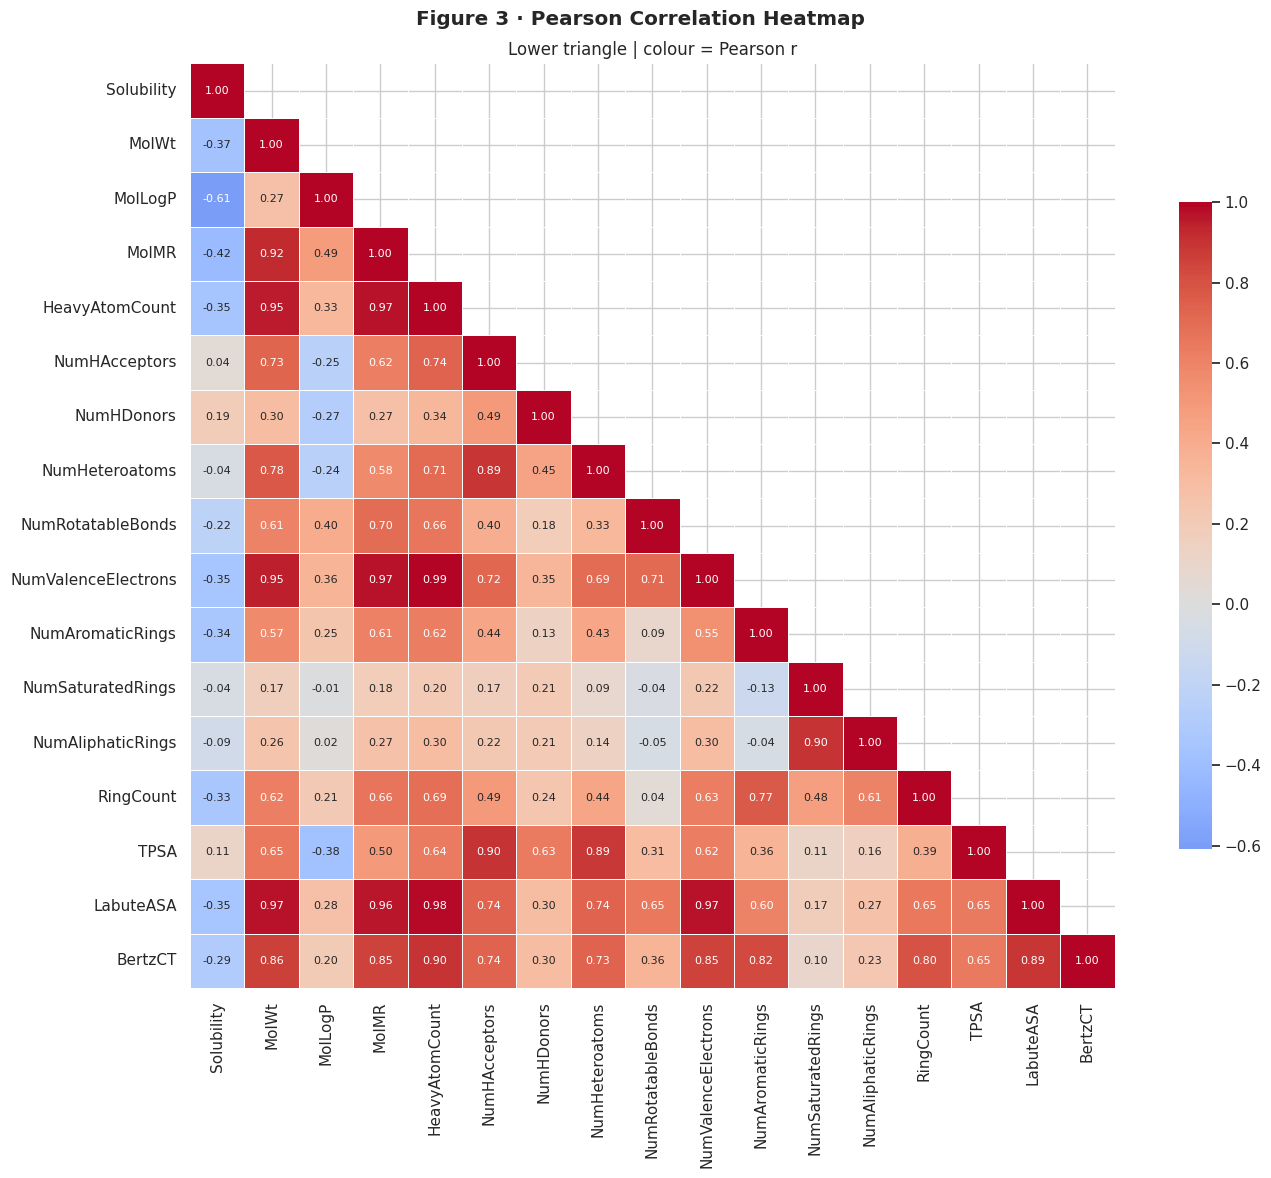

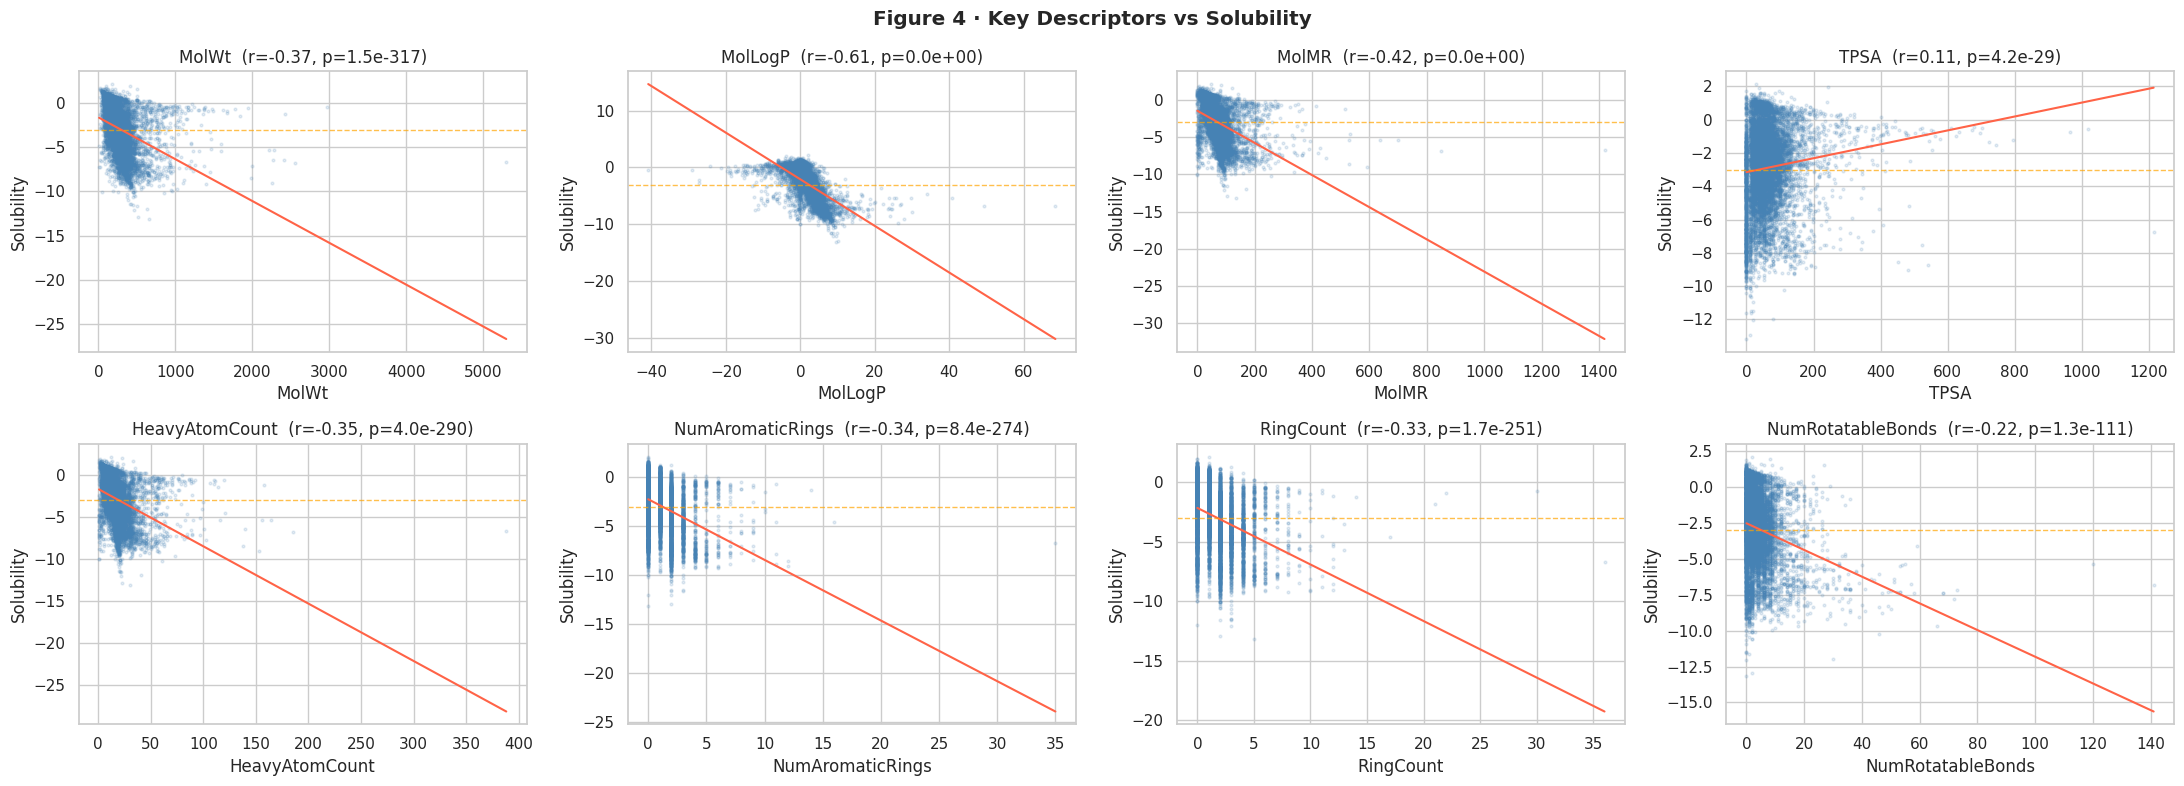

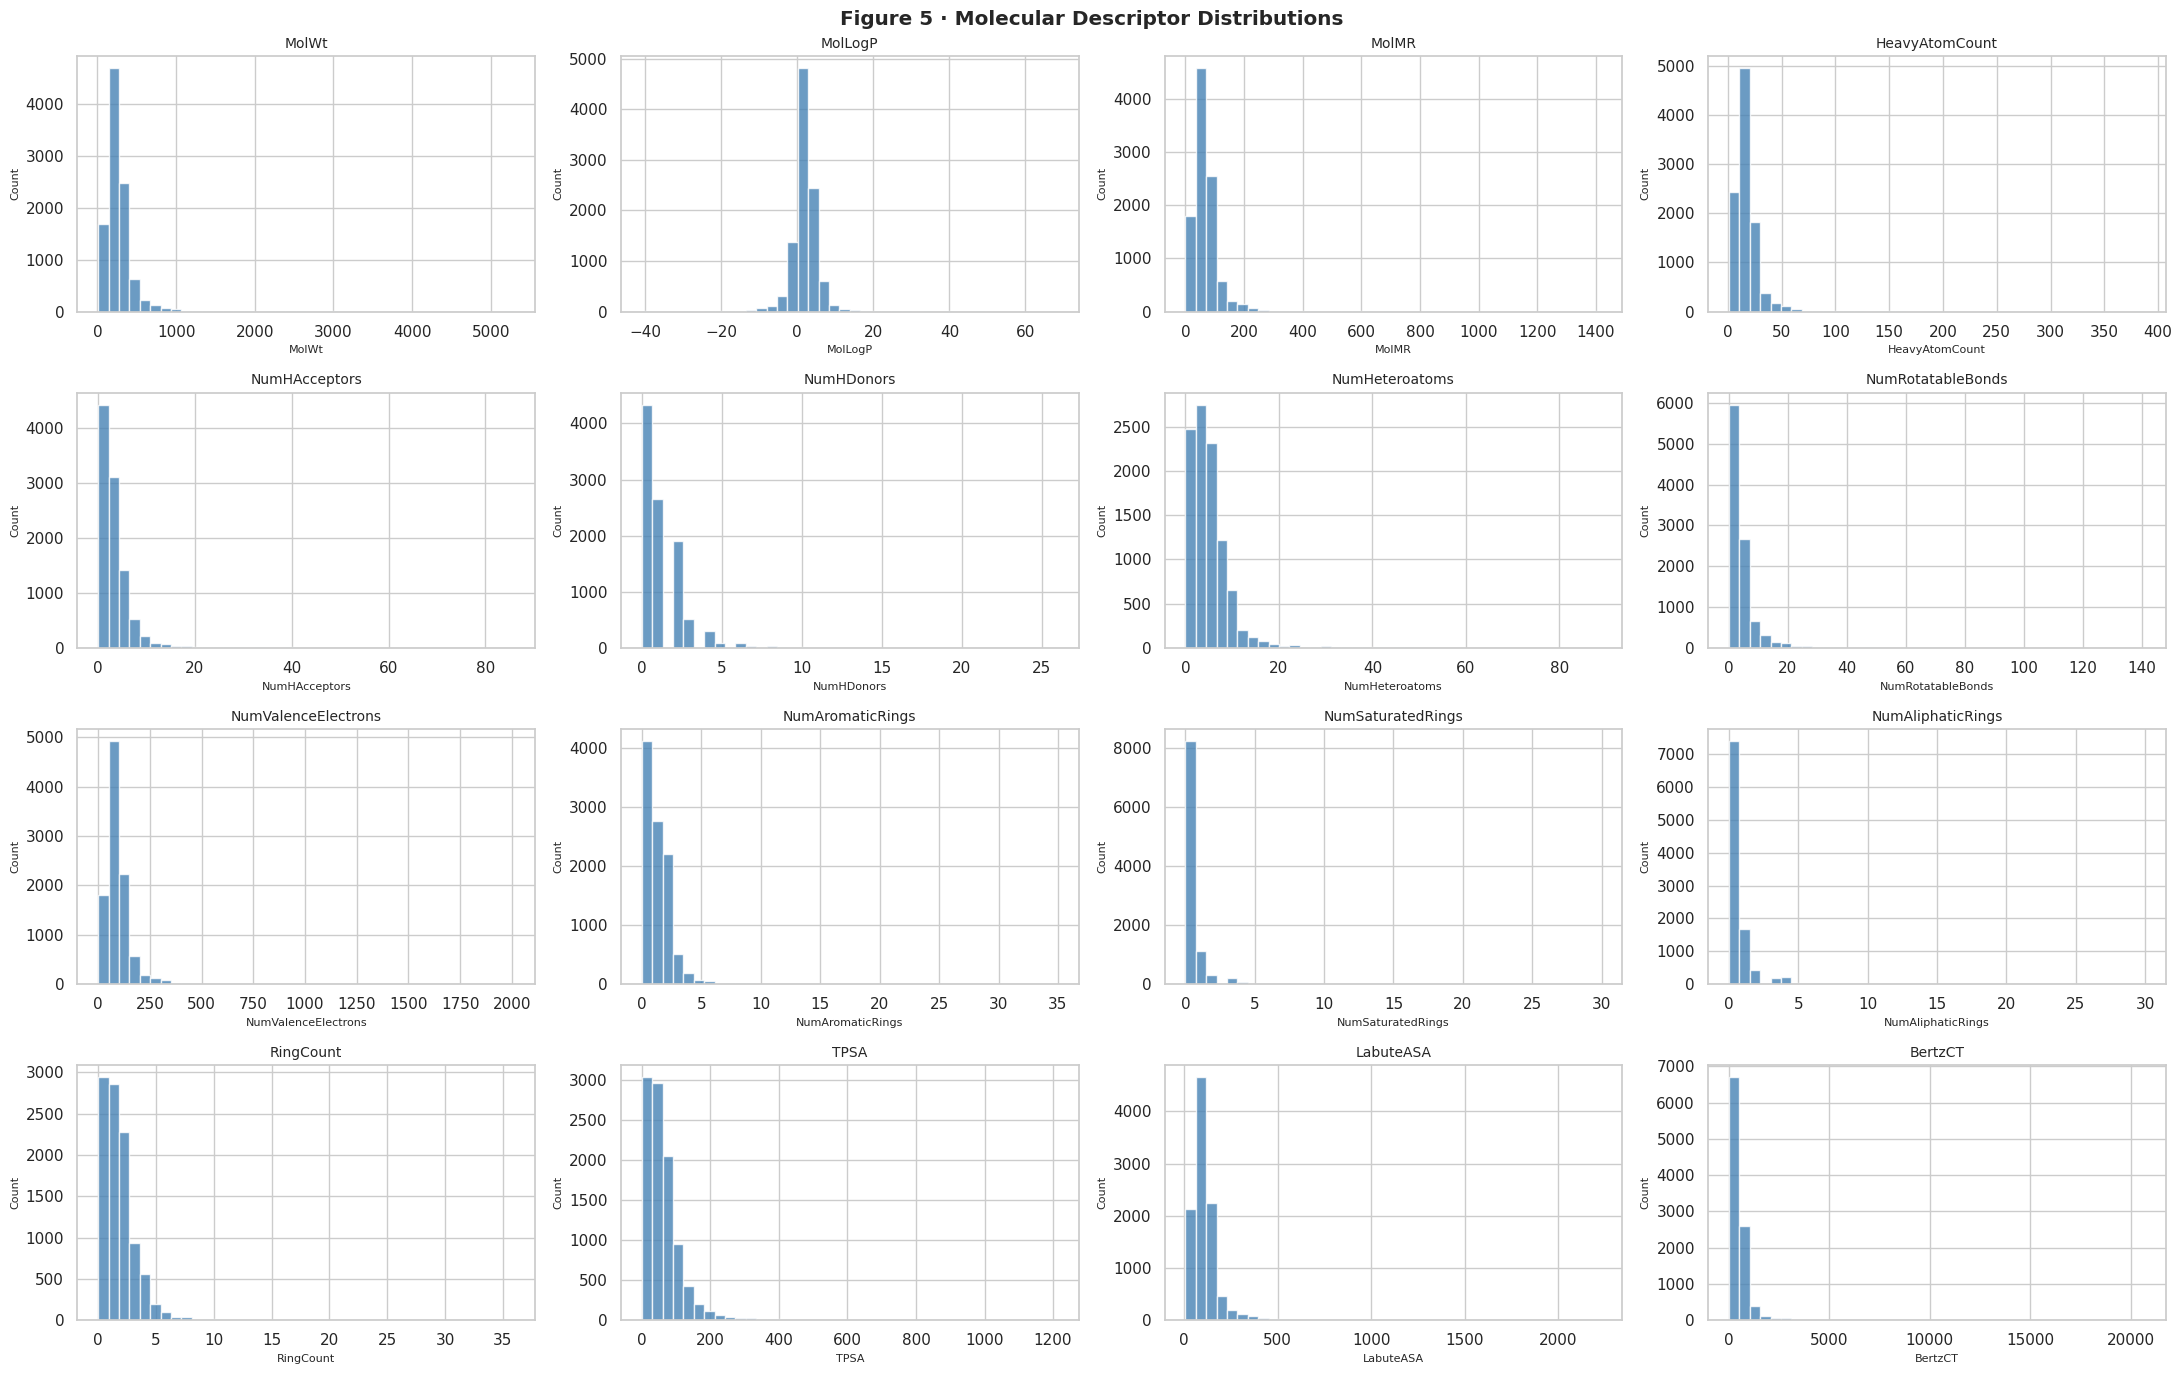

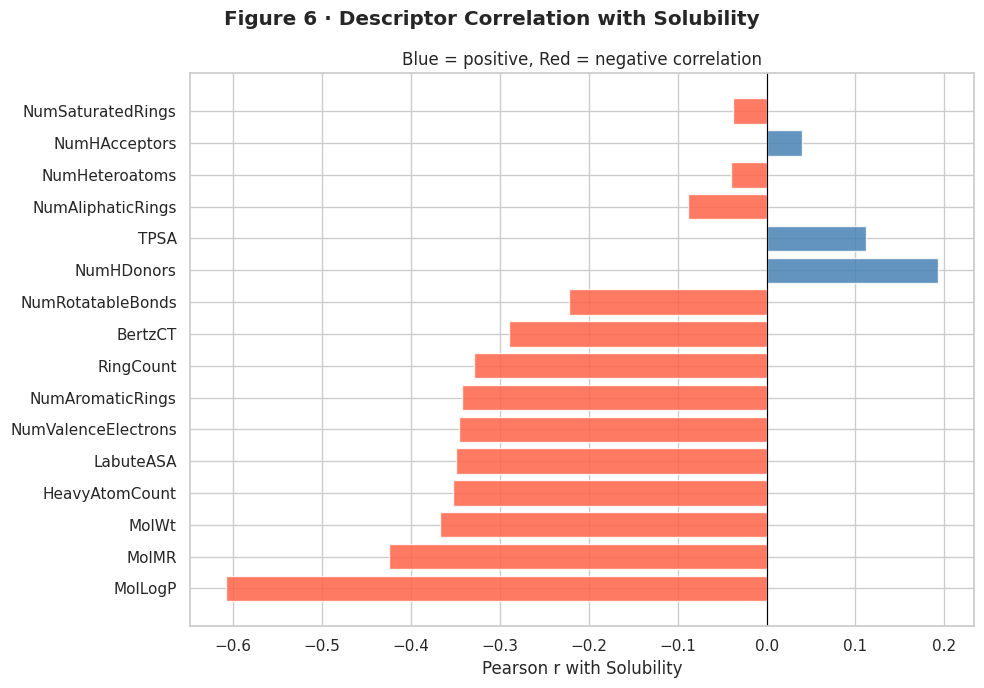

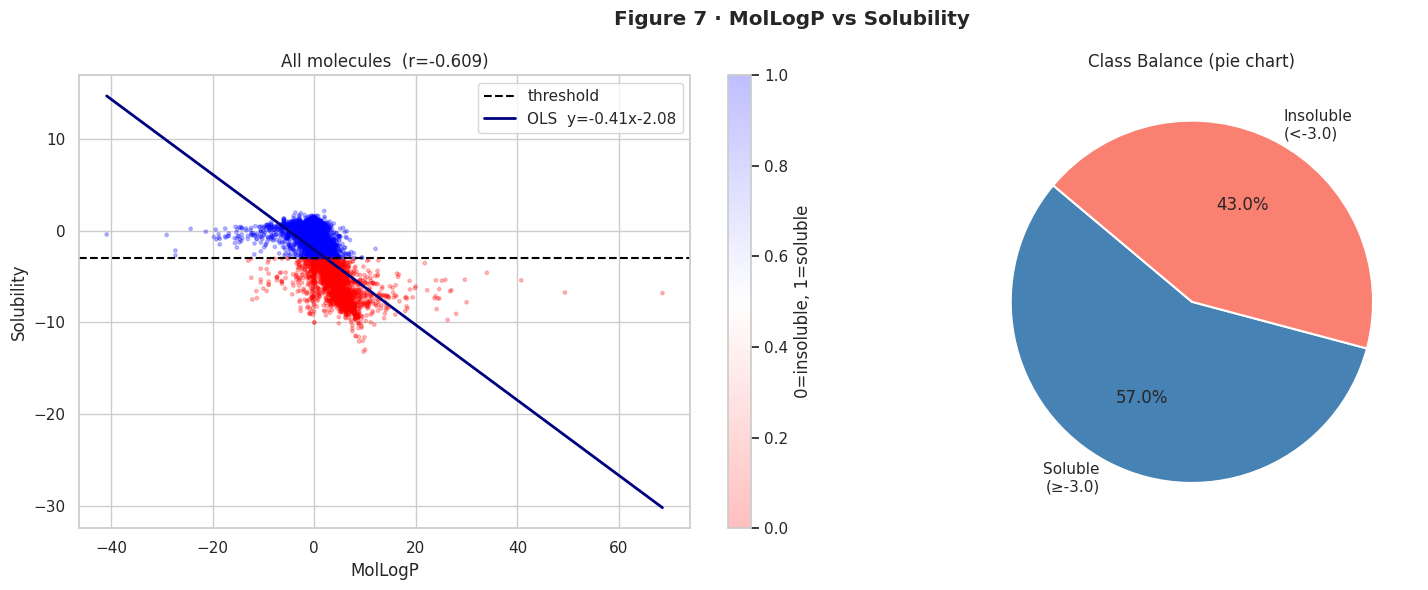

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 100})

df = clean_frame.copy()

DESCRIPTORS = [
    "MolWt", "MolLogP", "MolMR", "HeavyAtomCount",
    "NumHAcceptors", "NumHDonors", "NumHeteroatoms", "NumRotatableBonds",
    "NumValenceElectrons", "NumAromaticRings", "NumSaturatedRings",
    "NumAliphaticRings", "RingCount", "TPSA", "LabuteASA", "BertzCT",
]
AVAIL = [c for c in DESCRIPTORS if c in df.columns]

# ─── Figure 1: Solubility distribution ───────────────────────────────────────
sol = df["Solubility"]
mu, sigma = sol.mean(), sol.std()
xr = np.linspace(sol.min() - 0.5, sol.max() + 0.5, 300)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Figure 1 · Solubility Distribution", fontweight="bold")

axes[0].hist(sol, bins=60, color="steelblue", edgecolor="white", alpha=0.85, density=True)
axes[0].plot(xr, stats.gaussian_kde(sol)(xr), color="navy", lw=2, label="KDE")
axes[0].plot(xr, stats.norm.pdf(xr, mu, sigma), color="tomato", lw=2, ls="--", label="Normal fit")
axes[0].axvline(mu, color="red", lw=1.5, ls="--", label=f"mean={mu:.2f}")
axes[0].axvline(CLASSIFICATION_THRESHOLD, color="orange", lw=1.5, ls=":", label=f"threshold={CLASSIFICATION_THRESHOLD}")
axes[0].set_xlabel("Solubility (log mol/L)")
axes[0].set_ylabel("Density")
axes[0].set_title("Histogram + KDE + Normal")
axes[0].legend(fontsize=8)
info = (f"n={len(df)}\nmean={mu:.2f}\nstd={sigma:.2f}\n"
        f"skew={stats.skew(sol):.2f}\nkurt={stats.kurtosis(sol):.2f}")
axes[0].text(0.97, 0.97, info, transform=axes[0].transAxes, va="top", ha="right",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6), fontsize=8)

(osm, osr), (slope, intercept, r) = stats.probplot(sol, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normal)")

axes[2].boxplot(sol.values, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[2].set_ylabel("Solubility")
axes[2].set_title("Box Plot")
axes[2].set_xticks([])

binary_labels = make_binary_labels(sol, threshold=CLASSIFICATION_THRESHOLD)
n_pos, n_neg = int(binary_labels.sum()), int((binary_labels == 0).sum())
axes[3].bar(["Soluble", "Insoluble"], [n_pos, n_neg],
            color=["steelblue", "salmon"], edgecolor="white", alpha=0.85)
axes[3].set_ylabel("Count")
axes[3].set_title(f"Class Split @ {CLASSIFICATION_THRESHOLD}\n({n_pos} soluble / {n_neg} insoluble)")
for bar, cnt in zip(axes[3].patches, [n_pos, n_neg]):
    axes[3].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{cnt / len(df) * 100:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# ─── Figure 2: Solubility by Group ───────────────────────────────────────────
if "Group" in df.columns:
    groups = sorted(df["Group"].dropna().unique())
    group_data = [df.loc[df["Group"] == g, "Solubility"].values for g in groups]
    fig, ax = plt.subplots(figsize=(max(10, len(groups)), 5))
    fig.suptitle("Figure 2 · Solubility by Group", fontweight="bold")
    bp = ax.boxplot(group_data, labels=groups, patch_artist=True, notch=False)
    for patch, color in zip(bp["boxes"], plt.cm.tab20.colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.axhline(CLASSIFICATION_THRESHOLD, color="orange", lw=1.5, ls="--",
               label=f"threshold={CLASSIFICATION_THRESHOLD}")
    ax.set_xlabel("Group")
    ax.set_ylabel("Solubility (log mol/L)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ─── Figure 3: Descriptor correlation heatmap ─────────────────────────────────
corr_cols = ["Solubility"] + AVAIL
corr_matrix = df[corr_cols].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(15, 12))
fig.suptitle("Figure 3 · Pearson Correlation Heatmap", fontweight="bold")
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, mask=mask,
            cbar_kws={"shrink": 0.7}, ax=ax, annot_kws={"size": 8})
ax.set_title("Lower triangle | colour = Pearson r")
plt.tight_layout()
plt.show()

# ─── Figure 4: Key descriptors vs Solubility scatter ─────────────────────────
KEY_DESC = [c for c in ["MolWt", "MolLogP", "MolMR", "TPSA",
                         "HeavyAtomCount", "NumAromaticRings",
                         "RingCount", "NumRotatableBonds"] if c in df.columns]
ncols = 4
nrows = (len(KEY_DESC) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 4))
fig.suptitle("Figure 4 · Key Descriptors vs Solubility", fontweight="bold")
axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else list(axes)

for i, col in enumerate(KEY_DESC):
    ax = axes_flat[i]
    valid = df[[col, "Solubility"]].dropna()
    r_val, pval = stats.pearsonr(valid[col], valid["Solubility"])
    ax.scatter(valid[col], valid["Solubility"], alpha=0.15, s=4,
               color="steelblue", rasterized=True)
    m, b = np.polyfit(valid[col], valid["Solubility"], 1)
    xr2 = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(xr2, m * xr2 + b, color="tomato", lw=1.5)
    ax.axhline(CLASSIFICATION_THRESHOLD, color="orange", lw=1, ls="--", alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel("Solubility")
    ax.set_title(f"{col}  (r={r_val:.2f}, p={pval:.1e})")

for j in range(len(KEY_DESC), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

# ─── Figure 5: All descriptor distributions ──────────────────────────────────
ncols = 4
nrows = (len(AVAIL) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
fig.suptitle("Figure 5 · Molecular Descriptor Distributions", fontweight="bold")
axes_flat2 = axes.flatten()

for i, col in enumerate(AVAIL):
    ax = axes_flat2[i]
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Count", fontsize=8)

for j in range(len(AVAIL), len(axes_flat2)):
    axes_flat2[j].set_visible(False)

plt.tight_layout()
plt.show()

# ─── Figure 6: Feature correlation ranking ────────────────────────────────────
corr_with_sol = (df[AVAIL].corrwith(df["Solubility"])
                           .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Figure 6 · Descriptor Correlation with Solubility", fontweight="bold")
colors_bar = ["tomato" if v < 0 else "steelblue" for v in corr_with_sol.values]
ax.barh(range(len(corr_with_sol)), corr_with_sol.values,
        color=colors_bar, edgecolor="white", alpha=0.85)
ax.set_yticks(range(len(corr_with_sol)))
ax.set_yticklabels(corr_with_sol.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with Solubility")
ax.set_title("Blue = positive, Red = negative correlation")
plt.tight_layout()
plt.show()

# ─── Figure 7: MolLogP vs Solubility coloured by class ───────────────────────
if "MolLogP" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Figure 7 · MolLogP vs Solubility", fontweight="bold")

    sc = axes[0].scatter(df["MolLogP"], df["Solubility"],
                         c=binary_labels.astype(float),
                         cmap="bwr_r", alpha=0.25, s=6, rasterized=True)
    axes[0].axhline(CLASSIFICATION_THRESHOLD, color="black", lw=1.5, ls="--", label="threshold")
    m2, b2 = np.polyfit(df["MolLogP"], df["Solubility"], 1)
    xr3 = np.linspace(df["MolLogP"].min(), df["MolLogP"].max(), 100)
    axes[0].plot(xr3, m2 * xr3 + b2, color="navy", lw=2,
                 label=f"OLS  y={m2:.2f}x{b2:+.2f}")
    plt.colorbar(sc, ax=axes[0], label="0=insoluble, 1=soluble")
    axes[0].set_xlabel("MolLogP")
    axes[0].set_ylabel("Solubility")
    r3, _ = stats.pearsonr(df["MolLogP"], df["Solubility"])
    axes[0].set_title(f"All molecules  (r={r3:.3f})")
    axes[0].legend()

    axes[1].pie([n_pos, n_neg],
                labels=[f"Soluble\n(≥{CLASSIFICATION_THRESHOLD})", f"Insoluble\n(<{CLASSIFICATION_THRESHOLD})"],
                colors=["steelblue", "salmon"],
                autopct="%1.1f%%", startangle=140,
                wedgeprops=dict(edgecolor="white", linewidth=1.5))
    axes[1].set_title("Class Balance (pie chart)")

    plt.tight_layout()
    plt.show()


## 3 · Tabular preprocessing (classical models + DNN)

Each molecule is converted to a fixed-length vector using:
- **Morgan fingerprints** — circular fingerprint encoded as a bit vector (radius=`FINGERPRINT_RADIUS`, bits=`FINGERPRINT_SIZE`)
- **RDKit descriptors** — 12 physicochemical properties (MolWt, MolLogP, TPSA, ...)
- **Combined** — fingerprint concatenated with descriptors (default)

The active mode is controlled by `FEATURE_MODE` in the hyperparameter cell.

In [52]:
# Build the feature matrix using the hyperparameters from Section 1
X, y, feature_frame, feature_names = build_classical_feature_matrix(
    clean_frame,
    descriptor_names=DESCRIPTOR_NAMES,
    fingerprint_radius=FINGERPRINT_RADIUS,
    fingerprint_size=FINGERPRINT_SIZE,
    feature_mode=FEATURE_MODE,
)

print(f"Feature mode : {FEATURE_MODE}")
print(f"X shape      : {X.shape}   (molecules × features)")
print(f"y shape      : {y.shape}")
print(f"dtype        : {X.dtype}")
print(f"\nFirst 10 feature names: {feature_names[:10]}")

# Optionally inspect all three modes side-by-side
summary_rows = []
for mode in ("fingerprint", "descriptor", "combined"):
    Xi, _, _, _ = build_classical_feature_matrix(
        clean_frame,
        fingerprint_radius=FINGERPRINT_RADIUS,
        fingerprint_size=FINGERPRINT_SIZE,
        feature_mode=mode,
    )
    summary_rows.append({"mode": mode, "features": Xi.shape[1], "rows": Xi.shape[0]})
display(pd.DataFrame(summary_rows))

Feature mode : combined
X shape      : (9980, 1036)   (molecules × features)
y shape      : (9980,)
dtype        : float32

First 10 feature names: ['fp_0000', 'fp_0001', 'fp_0002', 'fp_0003', 'fp_0004', 'fp_0005', 'fp_0006', 'fp_0007', 'fp_0008', 'fp_0009']


,mode,features,rows
0,fingerprint,1024,9980
1,descriptor,12,9980
2,combined,1036,9980


## 4 · Graph preprocessing (GNN models)

Each molecule is converted into a `torch_geometric.data.Data` object:
- **`x`** (node features): atom properties — variant controlled by `GRAPH_FEATURE_VARIANT`
  - `atomic_number` → 1 feature per atom
  - `atomic_number_degree` → 2 features
  - `full` → 3 features (atomic number, degree, is_aromatic)
- **`edge_index`**: COO-format adjacency (directed, both directions)
- **`edge_attr`**: bond type weight (1.0=single, 2.0=double, 3.0=triple, 1.5=other)
- **`y`**: solubility scalar

In [53]:
graph_dataset = build_graph_dataset(clean_frame, feature_variant=GRAPH_FEATURE_VARIANT)

node_counts = np.array([g.x.shape[0] for g in graph_dataset])
edge_counts = np.array([g.edge_index.shape[1] for g in graph_dataset])

print(f"Graph feature variant : {GRAPH_FEATURE_VARIANT}")
print(f"Number of graphs      : {len(graph_dataset)}")
print(f"Node feature dim      : {graph_dataset[0].x.shape[1]}")
print(f"Avg atoms per mol     : {node_counts.mean():.1f}  (median {np.median(node_counts):.0f})")
print(f"Avg edges per mol     : {edge_counts.mean():.1f}  (median {np.median(edge_counts):.0f})")
print()
sample = graph_dataset[0]
print("Sample graph:", sample)
print("  x         :", sample.x.shape, "— node features")
print("  edge_index:", sample.edge_index.shape, "— COO connectivity")
print("  edge_attr :", sample.edge_attr.shape, "— bond weights")
print("  y         :", sample.y.item(), "— solubility")

Graph feature variant : full
Number of graphs      : 9980
Node feature dim      : 3
Avg atoms per mol     : 17.4  (median 15)
Avg edges per mol     : 35.3  (median 30)

Sample graph: Data(x=[23, 3], edge_index=[2, 42], edge_attr=[42, 1], y=[1], name='N,N,N-trimethyloctadecan-1-aminium bromide', smiles='[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C')
  x         : torch.Size([23, 3]) — node features
  edge_index: torch.Size([2, 42]) — COO connectivity
  edge_attr : torch.Size([42, 1]) — bond weights
  y         : -3.6161270141601562 — solubility


## 5 · Data splitting

**Tabular path** (`split_classical_data`):
- Train / test split using `TEST_SIZE` and `RANDOM_STATE`
- DNN models further split train into fit/val using `VAL_FRACTION`

**Graph path** (same logic, applied to list of `Data` objects)

In [54]:
from sklearn.model_selection import train_test_split

# Tabular split
X_train, X_test, y_train, y_test, frame_train, frame_test = split_classical_data(
    X, y, feature_frame,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

# Graph split
train_graphs, test_graphs, _, gframe_test = train_test_split(
    graph_dataset, clean_frame,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)
fit_graphs, val_graphs = train_test_split(
    train_graphs,
    test_size=VAL_FRACTION,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("Tabular split")
print(f"  train: {X_train.shape[0]} rows   test: {X_test.shape[0]} rows   features: {X_train.shape[1]}")
print()
print("Graph split")
print(f"  fit: {len(fit_graphs)} graphs   val: {len(val_graphs)} graphs   test: {len(test_graphs)} graphs")

Tabular split
  train: 7984 rows   test: 1996 rows   features: 1036

Graph split
  fit: 6786 graphs   val: 1198 graphs   test: 1996 graphs


## 6 · Classical regression models

Each model's `train_and_evaluate()` runs the full pipeline internally (data load → feature extraction → split → fit → save to `outputs/`).
The functions accept the same hyperparameters you set in Section 1.

### 6a · Linear Regression

Baseline model — ordinary least-squares via scikit-learn. No free hyperparameters beyond the feature mode.

In [55]:
from train.train_linear_regression import train_and_evaluate as train_linear_regression

lr_metrics = {}
if RUN_LINEAR_REGRESSION:
    print("Training Linear Regression ...")
    lr_metrics = train_linear_regression(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        feature_mode=FEATURE_MODE,
    )
    print("Linear Regression metrics:", json.dumps(lr_metrics, indent=2))
else:
    print("Skipped (RUN_LINEAR_REGRESSION = False)")

Training Linear Regression ...


[17:44:48] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:44:48] Explicit valence for atom # 5 N, 4, is greater than permitted


Linear Regression metrics: {
  "rmse": 1.571513056755066,
  "mae": 1.1913944482803345,
  "r2": 0.5444774627685547,
  "feature_mode": "combined",
  "num_features": 1036,
  "train_rows": 7984,
  "test_rows": 1996
}


### 6b · Gaussian Process Regressor

Uses an RBF kernel. Tunable via `GP_LENGTH_SCALE` and `GP_ALPHA`.
Fitting can be slow on the full feature set — set `RUN_GAUSSIAN_PROCESS = True` only when you have time.

In [56]:
from train.train_gaussian_process import train_and_evaluate as train_gaussian_process

gp_metrics = {}
if RUN_GAUSSIAN_PROCESS:
    print("Training Gaussian Process Regressor (this may take a while) ...")
    gp_metrics = train_gaussian_process(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        length_scale=GP_LENGTH_SCALE,
        alpha=GP_ALPHA,
        feature_mode=FEATURE_MODE,
    )
    print("GP Regressor metrics:", json.dumps(gp_metrics, indent=2))
else:
    print("Skipped (RUN_GAUSSIAN_PROCESS = False). Set it True in the hyperparameter cell to enable.")

Skipped (RUN_GAUSSIAN_PROCESS = False). Set it True in the hyperparameter cell to enable.


### 6c · MLP Regressor (scikit-learn)

Scikit-learn's `MLPRegressor` with Adam solver, ReLU activations, and early stopping.
Tunable via `SKLEARN_MLP_*` parameters.

In [57]:
from train.train_mlp_regressor import train_and_evaluate as train_mlp_regressor

mlp_metrics = {}
if RUN_SKLEARN_MLP:
    print("Training sklearn MLP Regressor ...")
    mlp_metrics = train_mlp_regressor(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        hidden_layers=SKLEARN_MLP_HIDDEN_LAYERS,
        alpha=SKLEARN_MLP_ALPHA,
        learning_rate_init=SKLEARN_MLP_LR_INIT,
        feature_mode=FEATURE_MODE,
    )
    print("Sklearn MLP metrics:", json.dumps(mlp_metrics, indent=2))
else:
    print("Skipped (RUN_SKLEARN_MLP = False)")

Training sklearn MLP Regressor ...


[17:45:05] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:45:05] Explicit valence for atom # 5 N, 4, is greater than permitted


Sklearn MLP metrics: {
  "rmse": 1.191145896911621,
  "mae": 0.827316164970398,
  "r2": 0.7382999658584595,
  "feature_mode": "combined",
  "num_features": 1036,
  "hidden_layers": [
    256,
    128,
    64
  ],
  "alpha": 0.0001,
  "learning_rate_init": 0.001,
  "train_rows": 7984,
  "test_rows": 1996
}


## 7 · Dense Neural Network (PyTorch)

A fully-connected network built with `DenseRegressor` from `DNN/dense_regressor.py`.

Architecture:
```
Input (1036) → Linear → ReLU → Dropout
             → Linear → ReLU → Dropout
             → Linear → ReLU → Dropout
             → Linear (output=1)
```

The train/val/test pipeline:
1. Tabular features extracted with `FEATURE_MODE`
2. Train split further divided into fit/val (15%)
3. `StandardScaler` fitted on fit set, applied to val & test
4. Adam optimiser, MSE loss, best-validation-loss checkpoint

In [58]:
from train.train_dense_regressor import train_and_evaluate as train_dense_regressor

dnn_metrics = {}
if RUN_DENSE_REGRESSOR:
    print("Training Dense Regressor ...")
    dnn_metrics = train_dense_regressor(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        hidden_layers=DNN_HIDDEN_DIMS,
        dropout=DNN_DROPOUT,
        epochs=DNN_EPOCHS,
        batch_size=DNN_BATCH_SIZE,
        learning_rate=DNN_LR,
        weight_decay=DNN_WEIGHT_DECAY,
        feature_mode=FEATURE_MODE,
    )
    print("Dense Regressor metrics:", json.dumps(dnn_metrics, indent=2))
else:
    print("Skipped (RUN_DENSE_REGRESSOR = False)")

Training Dense Regressor ...


[17:47:08] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:47:08] Explicit valence for atom # 5 N, 4, is greater than permitted


Dense Regressor metrics: {
  "rmse": 1.2307862043380737,
  "mae": 0.8683099746704102,
  "r2": 0.7205918431282043,
  "feature_mode": "combined",
  "num_features": 1036,
  "hidden_layers": [
    256,
    128,
    64
  ],
  "dropout": 0.15,
  "epochs": 150,
  "batch_size": 64,
  "learning_rate": 0.001,
  "weight_decay": 1e-05,
  "train_rows": 7984,
  "test_rows": 1996
}


## 8 · Graph Neural Network models

All four GNN architectures operate on the same graph representation but use different message-passing schemes:

| Model | Key idea |
|-------|----------|
| **GraphCN** | 3-layer residual GCN stack with batch norm |
| **GraphNET** | Multi-head attention stack with residual updates |
| **GraphSAGE** | Deeper GraphSAGE encoder with residual mixing |
| **GraphMP** | Edge-aware custom message passing using bond weights |

Every model reads `GNN_*` parameters from the hyperparameter cell.
All use: repeated message passing, batch normalisation, residual connections, mean+max pooling, and a small regression head.

In [59]:
from train.train_graph_cn import train_and_evaluate as train_graph_cn

gcn_metrics = {}
if RUN_GRAPH_CN:
    print("Training GraphCN ...")
    gcn_metrics = train_graph_cn(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        hidden_channels=GNN_HIDDEN_CHANNELS,
        epochs=GNN_EPOCHS,
        batch_size=GNN_BATCH_SIZE,
        learning_rate=GNN_LR,
        weight_decay=GNN_WEIGHT_DECAY,
    )
    print("GraphCN metrics:", json.dumps(gcn_metrics, indent=2))
else:
    print("Skipped (RUN_GRAPH_CN = False)")

Training GraphCN ...


[17:48:31] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:48:31] Explicit valence for atom # 5 N, 4, is greater than permitted


GraphCN metrics: {
  "rmse": 2.1551601179657967,
  "mae": 1.7188695041486772,
  "r2": 0.14329172281851588,
  "hidden_channels": 128,
  "epochs": 180,
  "batch_size": 32,
  "learning_rate": 0.0005,
  "weight_decay": 0.0001,
  "train_graphs": 7984,
  "test_graphs": 1996
}


In [60]:
from train.train_graph_net import train_and_evaluate as train_graph_net

gnet_metrics = {}
if RUN_GRAPH_NET:
    print("Training GraphNET ...")
    gnet_metrics = train_graph_net(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        hidden_channels=GNN_HIDDEN_CHANNELS,
        epochs=GNN_EPOCHS,
        batch_size=GNN_BATCH_SIZE,
        learning_rate=GNN_LR,
        weight_decay=GNN_WEIGHT_DECAY,
    )
    print("GraphNET metrics:", json.dumps(gnet_metrics, indent=2))
else:
    print("Skipped (RUN_GRAPH_NET = False)")

Training GraphNET ...


[17:52:06] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:52:06] Explicit valence for atom # 5 N, 4, is greater than permitted


GraphNET metrics: {
  "rmse": 2.24274753350157,
  "mae": 1.790843693380274,
  "r2": 0.07224211305459116,
  "hidden_channels": 128,
  "epochs": 180,
  "batch_size": 32,
  "learning_rate": 0.0005,
  "weight_decay": 0.0001,
  "train_graphs": 7984,
  "test_graphs": 1996
}


In [61]:
from train.train_graph_sage import train_and_evaluate as train_graph_sage

gsage_metrics = {}
if RUN_GRAPH_SAGE:
    print("Training GraphSAGE ...")
    gsage_metrics = train_graph_sage(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        hidden_channels=GNN_HIDDEN_CHANNELS,
        epochs=GNN_EPOCHS,
        batch_size=GNN_BATCH_SIZE,
        learning_rate=GNN_LR,
        weight_decay=GNN_WEIGHT_DECAY,
    )
    print("GraphSAGE metrics:", json.dumps(gsage_metrics, indent=2))
else:
    print("Skipped (RUN_GRAPH_SAGE = False)")

Training GraphSAGE ...


[17:56:22] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:56:23] Explicit valence for atom # 5 N, 4, is greater than permitted


GraphSAGE metrics: {
  "rmse": 2.1100045307955906,
  "mae": 1.6898546357327593,
  "r2": 0.17881566662614157,
  "hidden_channels": 128,
  "epochs": 180,
  "batch_size": 32,
  "learning_rate": 0.0005,
  "weight_decay": 0.0001,
  "train_graphs": 7984,
  "test_graphs": 1996
}


In [62]:
from train.train_graph_mp import train_and_evaluate as train_graph_mp

gmp_metrics = {}
if RUN_GRAPH_MP:
    print("Training GraphMP ...")
    gmp_metrics = train_graph_mp(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        hidden_channels=GNN_HIDDEN_CHANNELS,
        epochs=GNN_EPOCHS,
        batch_size=GNN_BATCH_SIZE,
        learning_rate=GNN_LR,
        weight_decay=GNN_WEIGHT_DECAY,
    )
    print("GraphMP metrics:", json.dumps(gmp_metrics, indent=2))
else:
    print("Skipped (RUN_GRAPH_MP = False)")

Training GraphMP ...


[17:57:59] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:57:59] Explicit valence for atom # 5 N, 4, is greater than permitted


GraphMP metrics: {
  "rmse": 2.1713064394856896,
  "mae": 1.733944900714041,
  "r2": 0.13040682950609872,
  "hidden_channels": 128,
  "epochs": 180,
  "batch_size": 32,
  "learning_rate": 0.0005,
  "weight_decay": 0.0001,
  "train_graphs": 7984,
  "test_graphs": 1996
}


## 10 · Post-Graph Algorithm Visualizations

These plots analyse the **graph representation** itself and, once GNN training cells have run,
the model predictions saved to `outputs/`.

| Figure | What it shows |
|--------|---------------|
| 8  | Graph size distribution — node & edge counts, size vs solubility |
| 9  | Atom type (atomic number) frequency + bond type breakdown |
| 10 | Atom degree distribution + aromaticity ratio |
| 11 | Actual vs Predicted solubility scatter for each GNN model |
| 12 | Training / validation loss curves |
| 13 | Residuals distribution, residuals vs actual, error vs molecule size |


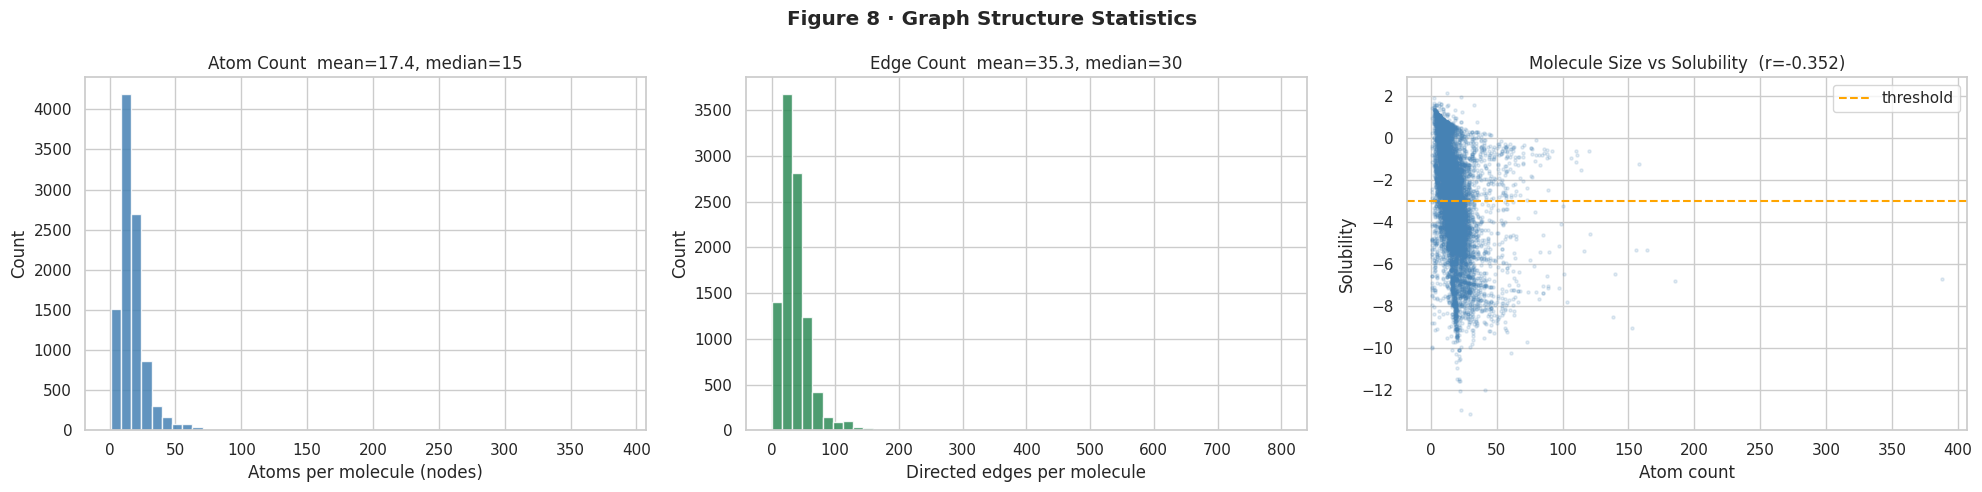

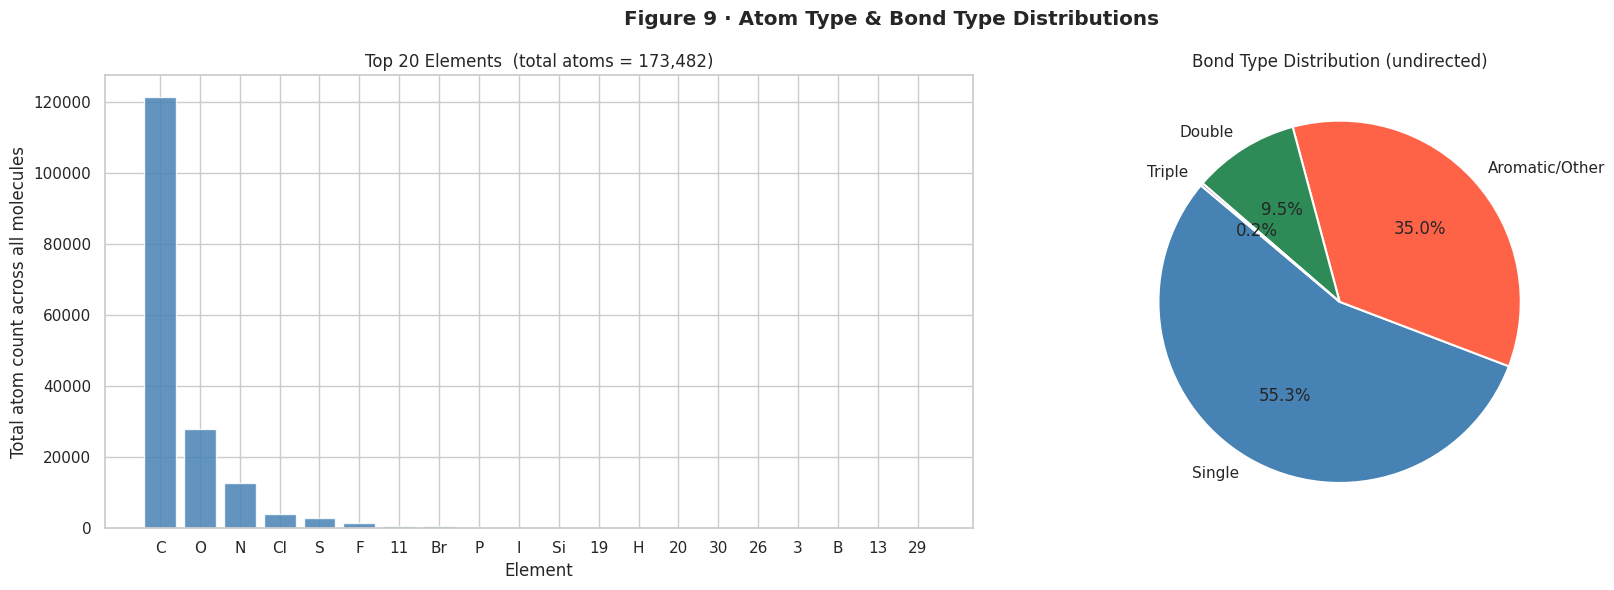

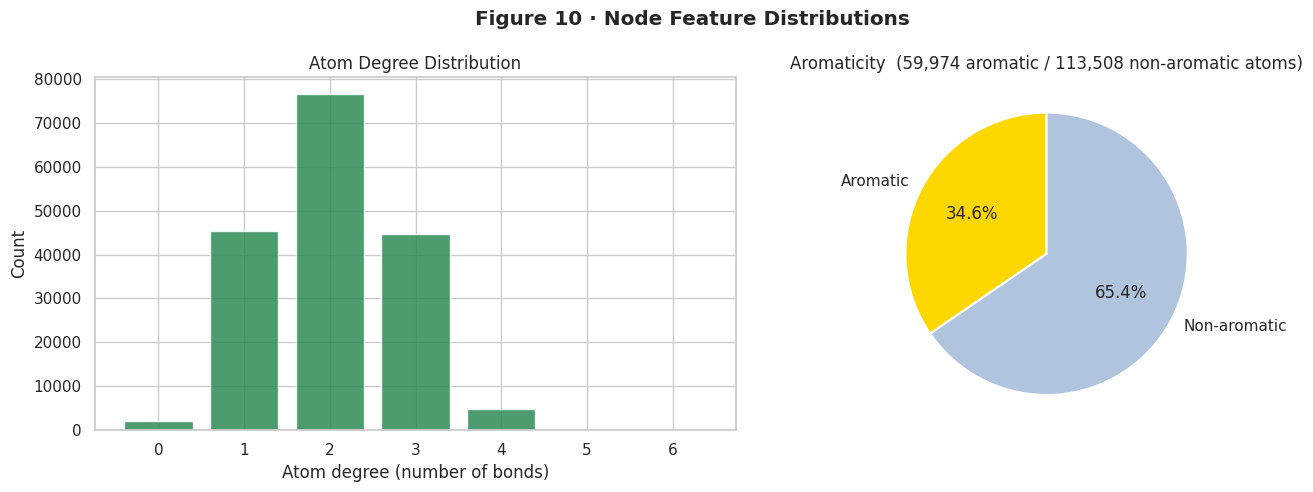

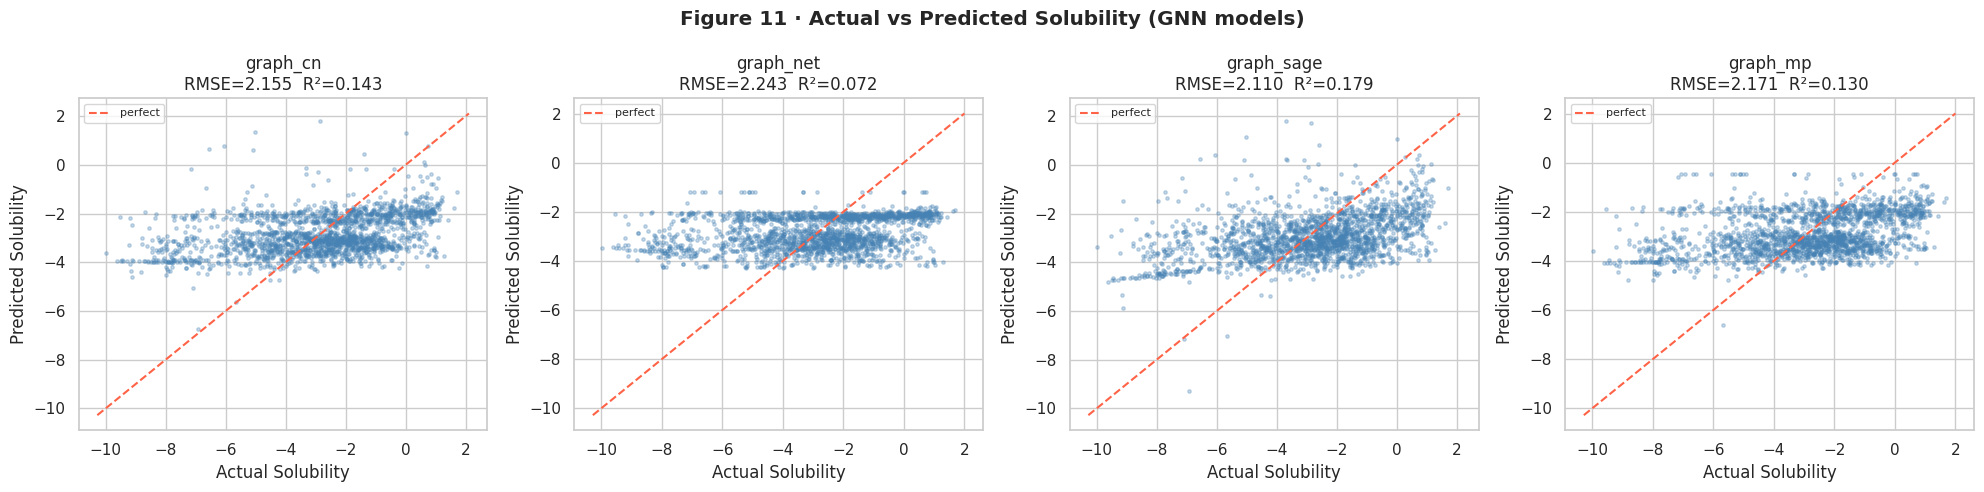

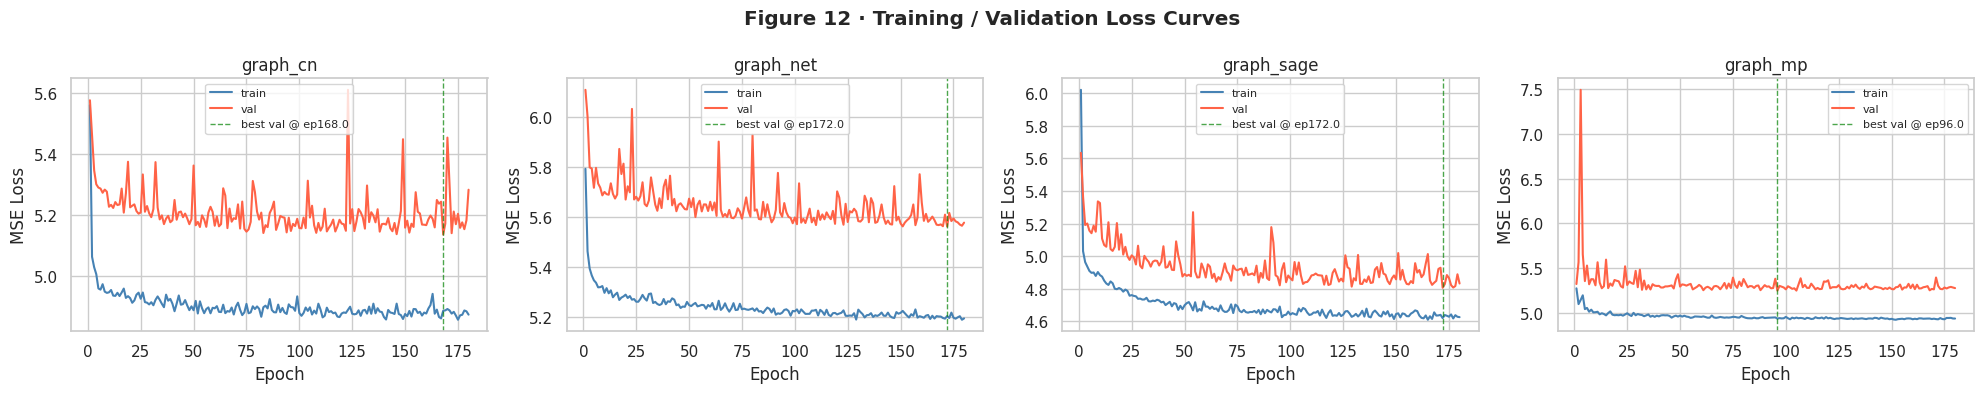

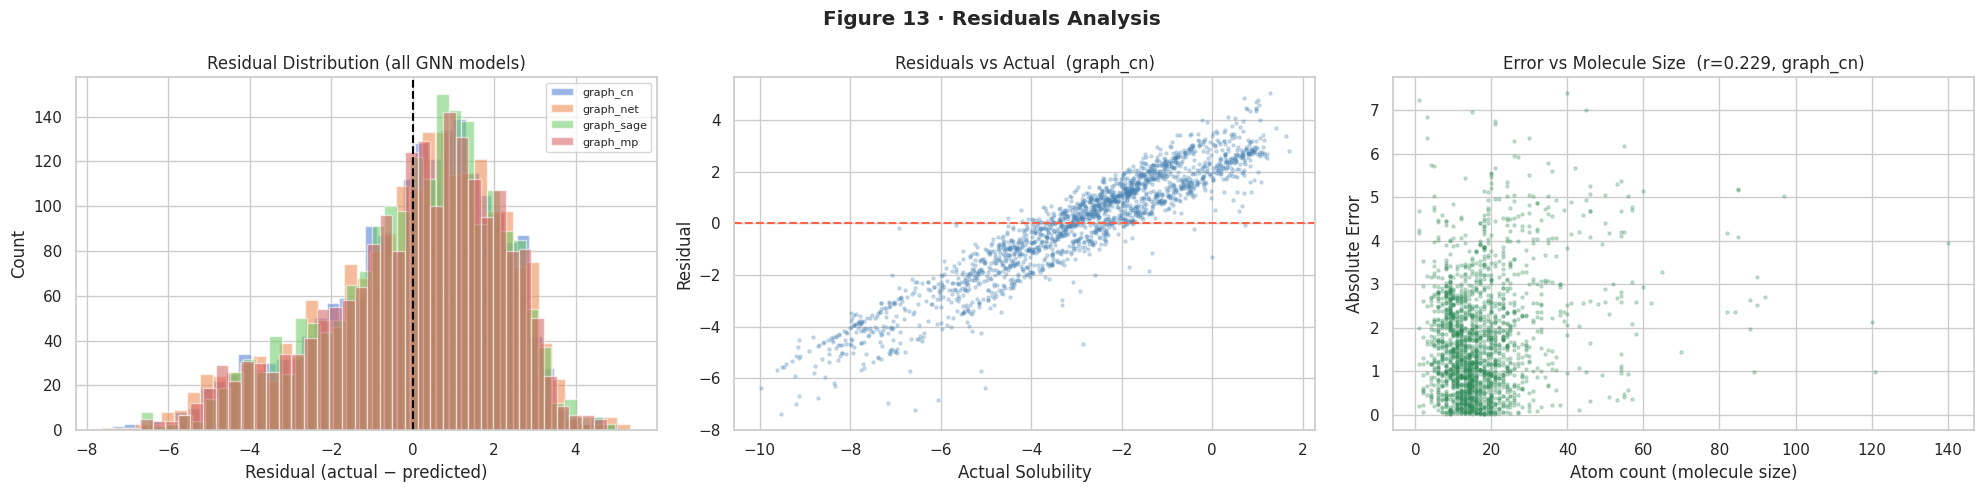

In [63]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as _stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 100})

# ─── Figure 8: Graph size statistics ─────────────────────────────────────────
node_counts = np.array([g.x.shape[0] for g in graph_dataset])
edge_counts = np.array([g.edge_index.shape[1] for g in graph_dataset])
sol_values  = np.array([g.y.item() for g in graph_dataset])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Figure 8 · Graph Structure Statistics", fontweight="bold")

axes[0].hist(node_counts, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Atoms per molecule (nodes)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Atom Count  mean={node_counts.mean():.1f}, median={np.median(node_counts):.0f}")

axes[1].hist(edge_counts, bins=50, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Directed edges per molecule")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Edge Count  mean={edge_counts.mean():.1f}, median={np.median(edge_counts):.0f}")

r_nc, _ = _stats.pearsonr(node_counts, sol_values)
axes[2].scatter(node_counts, sol_values, alpha=0.15, s=5, color="steelblue", rasterized=True)
axes[2].axhline(CLASSIFICATION_THRESHOLD, color="orange", lw=1.5, ls="--", label="threshold")
axes[2].set_xlabel("Atom count")
axes[2].set_ylabel("Solubility")
axes[2].set_title(f"Molecule Size vs Solubility  (r={r_nc:.3f})")
axes[2].legend()

plt.tight_layout()
plt.show()

# ─── Figure 9: Atom type + bond type ─────────────────────────────────────────
all_atomic_nums = torch.cat([g.x[:, 0] for g in graph_dataset]).numpy().astype(int)
unique_atoms, atom_counts = np.unique(all_atomic_nums, return_counts=True)

ELEMENT_MAP = {1:"H",5:"B",6:"C",7:"N",8:"O",9:"F",14:"Si",15:"P",
               16:"S",17:"Cl",35:"Br",53:"I",79:"Au",80:"Hg"}
elem_labels = [ELEMENT_MAP.get(a, str(a)) for a in unique_atoms]
order = np.argsort(-atom_counts)
top_n = min(20, len(unique_atoms))

all_edge_attrs = torch.cat([g.edge_attr.squeeze(-1) for g in graph_dataset]).numpy()
bond_map = {1.0: "Single", 2.0: "Double", 3.0: "Triple", 1.5: "Aromatic/Other"}
bond_vals, bond_cnts = np.unique(all_edge_attrs, return_counts=True)
bond_labels_list = [bond_map.get(float(v), f"{v:.1f}") for v in bond_vals]
bond_cnts_undir = bond_cnts // 2

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Figure 9 · Atom Type & Bond Type Distributions", fontweight="bold")

axes[0].bar(range(top_n),
            [atom_counts[i] for i in order[:top_n]],
            color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xticks(range(top_n))
axes[0].set_xticklabels([elem_labels[i] for i in order[:top_n]])
axes[0].set_xlabel("Element")
axes[0].set_ylabel("Total atom count across all molecules")
axes[0].set_title(f"Top {top_n} Elements  (total atoms = {len(all_atomic_nums):,})")

axes[1].pie(bond_cnts_undir, labels=bond_labels_list,
            colors=["steelblue", "tomato", "seagreen", "mediumpurple"],
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Bond Type Distribution (undirected)")

plt.tight_layout()
plt.show()

# ─── Figure 10: Degree & aromaticity ─────────────────────────────────────────
all_degrees   = torch.cat([g.x[:, 1] for g in graph_dataset]).numpy().astype(int)
all_aromatic  = torch.cat([g.x[:, 2] for g in graph_dataset]).numpy()

deg_vals, deg_cnts = np.unique(all_degrees, return_counts=True)
n_arom    = int(all_aromatic.sum())
n_nonarom = len(all_aromatic) - n_arom

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 10 · Node Feature Distributions", fontweight="bold")

axes[0].bar(deg_vals, deg_cnts, color="seagreen", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Atom degree (number of bonds)")
axes[0].set_ylabel("Count")
axes[0].set_title("Atom Degree Distribution")

axes[1].pie([n_arom, n_nonarom],
            labels=["Aromatic", "Non-aromatic"],
            colors=["gold", "lightsteelblue"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title(f"Aromaticity  ({n_arom:,} aromatic / {n_nonarom:,} non-aromatic atoms)")

plt.tight_layout()
plt.show()

# ─── Figures 11-13: Post-training (from saved outputs) ───────────────────────
GNN_MODEL_NAMES = ["graph_cn", "graph_net", "graph_sage", "graph_mp"]
prediction_dfs, history_dfs = {}, {}

for mname in GNN_MODEL_NAMES:
    pred_path = OUTPUTS_DIR / "graphml" / mname / "predictions.csv"
    hist_path = OUTPUTS_DIR / "graphml" / mname / "history.csv"
    if pred_path.exists():
        prediction_dfs[mname] = pd.read_csv(pred_path)
    if hist_path.exists():
        history_dfs[mname] = pd.read_csv(hist_path)

if not prediction_dfs:
    print("No GNN predictions saved yet.  Run the GNN training cells in Section 9 first.")
else:
    # Figure 11: Actual vs Predicted scatter ───────────────────────────────────
    n_m = len(prediction_dfs)
    fig, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 5), squeeze=False)
    fig.suptitle("Figure 11 · Actual vs Predicted Solubility (GNN models)", fontweight="bold")

    for ci, (mname, pred_df) in enumerate(prediction_dfs.items()):
        ax = axes[0][ci]
        act, pred = pred_df["actual_Solubility"], pred_df["predicted_Solubility"]
        rmse = float(np.sqrt(((act - pred) ** 2).mean()))
        r2   = float(1 - ((act - pred) ** 2).sum() / ((act - act.mean()) ** 2).sum())
        ax.scatter(act, pred, alpha=0.3, s=6, color="steelblue", rasterized=True)
        lo = min(act.min(), pred.min()) - 0.3
        hi = max(act.max(), pred.max()) + 0.3
        ax.plot([lo, hi], [lo, hi], color="tomato", lw=1.5, ls="--", label="perfect")
        ax.set_xlabel("Actual Solubility")
        ax.set_ylabel("Predicted Solubility")
        ax.set_title(f"{mname}\nRMSE={rmse:.3f}  R²={r2:.3f}")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Figure 12: Loss curves ──────────────────────────────────────────────────
    if history_dfs:
        n_h = len(history_dfs)
        fig, axes = plt.subplots(1, n_h, figsize=(5 * n_h, 4), squeeze=False)
        fig.suptitle("Figure 12 · Training / Validation Loss Curves", fontweight="bold")

        for ci, (mname, hist_df) in enumerate(history_dfs.items()):
            ax = axes[0][ci]
            ax.plot(hist_df["epoch"], hist_df["train_loss"],
                    label="train", color="steelblue", lw=1.5)
            ax.plot(hist_df["epoch"], hist_df["val_loss"],
                    label="val",   color="tomato",   lw=1.5)
            best_ep = hist_df.loc[hist_df["val_loss"].idxmin(), "epoch"]
            ax.axvline(best_ep, color="green", lw=1, ls="--", alpha=0.7,
                       label=f"best val @ ep{best_ep}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("MSE Loss")
            ax.set_title(mname)
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

    # Figure 13: Residuals ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle("Figure 13 · Residuals Analysis", fontweight="bold")

    for mname, pred_df in prediction_dfs.items():
        axes[0].hist(pred_df["residual"], bins=40, alpha=0.55,
                     label=mname, edgecolor="white")
    axes[0].axvline(0, color="black", lw=1.5, ls="--")
    axes[0].set_xlabel("Residual (actual − predicted)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Residual Distribution (all GNN models)")
    axes[0].legend(fontsize=8)

    first_name = list(prediction_dfs.keys())[0]
    fd = prediction_dfs[first_name]
    axes[1].scatter(fd["actual_Solubility"], fd["residual"],
                    alpha=0.25, s=5, color="steelblue", rasterized=True)
    axes[1].axhline(0, color="tomato", lw=1.5, ls="--")
    axes[1].set_xlabel("Actual Solubility")
    axes[1].set_ylabel("Residual")
    axes[1].set_title(f"Residuals vs Actual  ({first_name})")

    name_to_nodes = {g.name: g.x.shape[0] for g in graph_dataset}
    fd2 = fd.copy()
    fd2["node_count"] = fd2["Name"].map(name_to_nodes)
    valid = fd2.dropna(subset=["node_count"])
    axes[2].scatter(valid["node_count"], valid["absolute_error"],
                    alpha=0.25, s=5, color="seagreen", rasterized=True)
    r_se, _ = _stats.pearsonr(valid["node_count"], valid["absolute_error"])
    axes[2].set_xlabel("Atom count (molecule size)")
    axes[2].set_ylabel("Absolute Error")
    axes[2].set_title(f"Error vs Molecule Size  (r={r_se:.3f}, {first_name})")

    plt.tight_layout()
    plt.show()


## 9 · Results comparison

Two views:
1. **Live results** — metrics collected from the cells above (only models you ran)
2. **Saved results** — scans `outputs/` for all `metrics.json` files from previous runs

In [64]:
# ── View 1: results from this notebook session ────────────────────────────────
live_results = [
    {"model": "linear_regression",   **lr_metrics},
    {"model": "gaussian_process",     **gp_metrics},
    {"model": "sklearn_mlp",          **mlp_metrics},
    {"model": "dense_regressor",      **dnn_metrics},
    {"model": "graph_cn",             **gcn_metrics},
    {"model": "graph_net",            **gnet_metrics},
    {"model": "graph_sage",           **gsage_metrics},
    {"model": "graph_mp",             **gmp_metrics},
]
# Filter to models that actually ran
live_results = [r for r in live_results if len(r) > 1]

if live_results:
    df_live = pd.DataFrame(live_results).sort_values("rmse")
    print("Results from this session (sorted by RMSE):")
    display(df_live)
else:
    print("No models ran in this session yet.")

Results from this session (sorted by RMSE):


,model,rmse,mae,r2,feature_mode,num_features,train_rows,test_rows,hidden_layers,alpha,learning_rate_init,dropout,epochs,batch_size,learning_rate,weight_decay,hidden_channels,train_graphs,test_graphs
1,sklearn_mlp,1.191146,0.827316,0.738300,combined,1036.0,7984.0,1996.0,"[256, 128, 64]",0.0001,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dense_regressor,1.230786,0.868310,0.720592,combined,1036.0,7984.0,1996.0,"[256, 128, 64]",NaN,NaN,0.15,150.0,64.0,0.0010,0.00001,NaN,NaN,NaN
0,linear_regression,1.571513,1.191394,0.544477,combined,1036.0,7984.0,1996.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,graph_sage,2.110005,1.689855,0.178816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0
3,graph_cn,2.155160,1.718870,0.143292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0
6,graph_mp,2.171306,1.733945,0.130407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0
4,graph_net,2.242748,1.790844,0.072242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0


In [65]:
# ── View 2: scan outputs/ for all saved metrics.json ─────────────────────────
def collect_saved_metrics(root: Path) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for path in sorted(root.rglob("metrics.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        rows.append({"path": str(path.relative_to(root)), **payload})
    return pd.DataFrame(rows)

saved = collect_saved_metrics(OUTPUTS_DIR)
if saved.empty:
    print("No saved metrics found. Run some experiment cells first.")
else:
    sort_col = "rmse" if "rmse" in saved.columns else saved.columns[1]
    print("All saved experiment results (sorted by RMSE):")
    display(saved.sort_values(sort_col))

All saved experiment results (sorted by RMSE):


,path,rmse,mae,r2,feature_mode,num_features,train_rows,test_rows,hidden_layers,alpha,learning_rate_init,dropout,epochs,batch_size,learning_rate,weight_decay,hidden_channels,train_graphs,test_graphs
1,classical/mlp_regressor/metrics.json,1.191146,0.827316,0.738300,combined,1036.0,7984.0,1996.0,"[256, 128, 64]",0.0001,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dnn/dense_regressor/metrics.json,1.230786,0.868310,0.720592,combined,1036.0,7984.0,1996.0,"[256, 128, 64]",NaN,NaN,0.15,150.0,64.0,0.0010,0.00001,NaN,NaN,NaN
0,classical/linear_regression/metrics.json,1.571513,1.191394,0.544477,combined,1036.0,7984.0,1996.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,graphml/graph_sage/metrics.json,2.110005,1.689855,0.178816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0
3,graphml/graph_cn/metrics.json,2.155160,1.718870,0.143292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0
4,graphml/graph_mp/metrics.json,2.171306,1.733945,0.130407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0
5,graphml/graph_net/metrics.json,2.242748,1.790844,0.072242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,32.0,0.0005,0.00010,128.0,7984.0,1996.0


## 10 · Hyperparameter tuning

Three tuning scripts are available:

| Script | What it does |
|--------|--------------|
| `tune_classical_models` | Linear regression baseline + RandomizedSearchCV for GP and sklearn-MLP |
| `tune_dnn` | Grid over `(hidden_layers, dropout, lr)` for the PyTorch dense model |
| `tune_graph_models` | Grid over `(hidden_channels, lr)` for GraphCN / GraphNET / GraphSAGE |

Results are saved to `outputs/tuning/`.  
Set `RUN_TUNING = True` in the hyperparameter cell to execute.

In [66]:
from tuning.tune_classical_models import main as tune_classical_models
from tuning.tune_dnn import main as tune_dnn
from tuning.tune_graph_models import main as tune_graph_models

if RUN_TUNING:
    print("=" * 60)
    print("Running classical model tuning ...")
    print("=" * 60)
    tune_classical_models()

    print("=" * 60)
    print("Running DNN tuning ...")
    print("=" * 60)
    tune_dnn()

    print("=" * 60)
    print("Running graph model tuning ...")
    print("=" * 60)
    tune_graph_models()
else:
    print("Tuning skipped (RUN_TUNING = False).")
    print("Set RUN_TUNING = True in Section 1 to run the full tuning sweeps.")

Tuning skipped (RUN_TUNING = False).
Set RUN_TUNING = True in Section 1 to run the full tuning sweeps.


In [67]:
# Read tuning CSVs if they exist
tuning_dir = OUTPUTS_DIR / "tuning"
for csv_file in sorted(tuning_dir.glob("*.csv")) if tuning_dir.exists() else []:
    print(f"\n── {csv_file.name} ─────────────────────────")
    display(pd.read_csv(csv_file))

## 11 · Binary classification ablation

The regression target is binarised:
```
label = 1  if  Solubility >= CLASSIFICATION_THRESHOLD  (soluble)
label = 0  otherwise                                    (insoluble)
```

Two ablation scripts:
- **`run_feature_ablation`** — compares LogisticRegression / GP-Classifier / sklearn-MLP / DenseClassifier across all three feature modes
- **`run_graph_ablation`** — compares GraphCN / GraphNET / GraphSAGE / GraphMP across all three node-feature variants

Results are saved to `outputs/ablation/`.

In [68]:
# Show class balance at the chosen threshold
labels = make_binary_labels(clean_frame["Solubility"], threshold=CLASSIFICATION_THRESHOLD)
positive_rate = labels.mean()
print(f"Threshold          : Solubility >= {CLASSIFICATION_THRESHOLD}")
print(f"Positive (soluble) : {positive_rate:.4f}  ({int(labels.sum())} / {len(labels)})")
print(f"Negative           : {1 - positive_rate:.4f}  ({int((labels == 0).sum())} / {len(labels)})")

Threshold          : Solubility >= -3.0
Positive (soluble) : 0.5696  (5685 / 9980)
Negative           : 0.4304  (4295 / 9980)


In [69]:
from ablation.run_feature_ablation import main as run_feature_ablation
from ablation.run_graph_ablation import main as run_graph_ablation

if RUN_ABLATION:
    print("=" * 60)
    print("Running tabular feature ablation ...")
    print("=" * 60)
    run_feature_ablation()

    print("=" * 60)
    print("Running graph node-feature ablation ...")
    print("=" * 60)
    run_graph_ablation()
else:
    print("Ablation skipped (RUN_ABLATION = False).")
    print("Set RUN_ABLATION = True in Section 1 to run classification ablation studies.")

Ablation skipped (RUN_ABLATION = False).
Set RUN_ABLATION = True in Section 1 to run classification ablation studies.


In [70]:
# Read ablation CSVs if they exist
ablation_dir = OUTPUTS_DIR / "ablation"
for csv_file in sorted(ablation_dir.glob("*.csv")) if ablation_dir.exists() else []:
    print(f"\n── {csv_file.name} ─────────────────────────")
    df_abl = pd.read_csv(csv_file)
    display(df_abl)